# Optical Activity: Rotation in a Quartz Plate

Quartz is uniaxial and optically active. Along its optic axis the two modes
are circular with the indices √(n_o² + κ²) ± κ, so a linear polarization
turns as it travels: by ρ d over a thickness d, with the rotatory power
ρ = 2πκ/λ0. `QuartzMaterial` holds this as a bianisotropic material in the
Tellegen form (D' = εE + ξH', B' = ζE + μH', ξ = iα, ζ = −iαᵀ) with the
Ghosh (1999) indices and the rotatory power of Lowry and Coode-Adams (1927),
formula (vi), at the vacuum wavelength.

A linear input is a sum of the two circular modes, so a single mode trace
does not show the rotation. This example splits the rays into both modes
with `BranchTracer` and adds the two branches coherently at the exit.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from optiland.materials import QuartzMaterial, quartz_rotatory_power
from optiland.optic import Optic
from optiland.rays import create_polarization
from optiland.raytrace.branches import BranchTracer


def z_cut_plate(material, thickness, wavelength):
    """A plate in air, its optic axis along the optical axis z."""
    plate = Optic()
    plate.surfaces.add(index=0, radius=np.inf, thickness=np.inf)
    plate.surfaces.add(
        index=1, thickness=thickness, material=material, is_stop=True,
        interaction_type="anisotropic",
    )  # fmt: skip
    plate.surfaces.add(index=2, thickness=5.0, interaction_type="anisotropic")
    plate.surfaces.add(index=3)
    plate.set_aperture(aperture_type="EPD", value=2.0)
    plate.fields.set_type(field_type="angle")
    plate.fields.add(y=0.0)
    plate.wavelengths.add(value=wavelength, is_primary=True)
    # Unpolarized: the coherent sums give the exit field of an x and a y input.
    plate.updater.set_polarization(create_polarization("unpolarized"))
    return plate


def rotation_deg(plate):
    """The azimuth of the exit field of an x input (degrees) and its
    ellipticity |Im(E_y / E_x)|."""
    result = BranchTracer(plate).trace_all(num_rays=1)
    e_x_input = np.asarray(result.coherent_fields()[0])[0]
    ratio = e_x_input[1] / e_x_input[0]
    return np.degrees(np.arctan(ratio.real)), abs(ratio.imag)

## The branches of a 1 mm plate

The two transmitted modes of the entrance face are the slow and the fast
circular mode; both reach the image.

In [2]:
wavelength = 0.5893  # µm, vacuum
plate = z_cut_plate(QuartzMaterial(hand="right"), 1.0, wavelength)
result = BranchTracer(plate).trace_all(num_rays=1)
for key in result.keys():
    print(key)

rho = float(np.ravel(quartz_rotatory_power(wavelength))[0])
print(f"rotatory power at {wavelength} um: {rho:.4f} deg/mm")

(('s1', 'T', 'slow'), ('s2', 'T'))
(('s1', 'T', 'fast'), ('s2', 'T'))
rotatory power at 0.5893 um: 21.7375 deg/mm


## Rotation against thickness

Right quartz turns x̂ toward −ŷ along +z (clockwise as seen by an observer
who looks toward the source), so the traced azimuth is −ρ d. The exit state
stays linear.

In [3]:
for d in (0.5, 1.0, 2.0, 3.0):
    for hand, sign in (("right", -1.0), ("left", 1.0)):
        psi, ellipticity = rotation_deg(
            z_cut_plate(QuartzMaterial(hand=hand), d, wavelength)
        )
        print(
            f"{hand:>5} quartz, d = {d:.1f} mm: azimuth {psi:+9.4f} deg,"
            f" minus the closed form {psi - sign * rho * d:+.1e} deg,"
            f" ellipticity {ellipticity:.0e}"
        )

right quartz, d = 0.5 mm: azimuth  -10.8687 deg, minus the closed form +1.2e-10 deg, ellipticity 2e-12
 left quartz, d = 0.5 mm: azimuth  +10.8687 deg, minus the closed form -1.2e-10 deg, ellipticity 6e-13


right quartz, d = 1.0 mm: azimuth  -21.7375 deg, minus the closed form +2.3e-10 deg, ellipticity 5e-12
 left quartz, d = 1.0 mm: azimuth  +21.7375 deg, minus the closed form -2.3e-10 deg, ellipticity 4e-12
right quartz, d = 2.0 mm: azimuth  -43.4749 deg, minus the closed form +4.7e-10 deg, ellipticity 3e-11


 left quartz, d = 2.0 mm: azimuth  +43.4749 deg, minus the closed form -4.7e-10 deg, ellipticity 2e-11


right quartz, d = 3.0 mm: azimuth  -65.2124 deg, minus the closed form -5.5e-10 deg, ellipticity 1e-10
 left quartz, d = 3.0 mm: azimuth  +65.2124 deg, minus the closed form +5.5e-10 deg, ellipticity 1e-10


## Rotatory dispersion

The rotatory power falls steeply with the wavelength. The traced rotation of
a 1 mm right-quartz plate follows `quartz_rotatory_power` (below 45° per mm
from 450 nm on, so the azimuth needs no unwrapping).

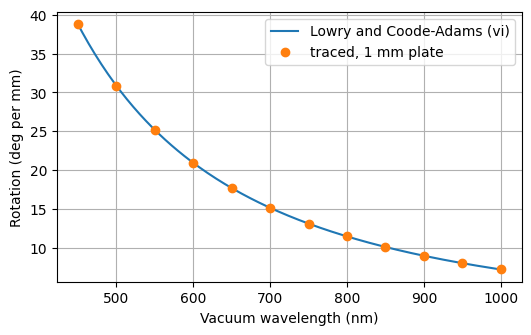

max |traced - formula| = 6.3e-10 deg


In [4]:
wavelengths = np.linspace(0.45, 1.0, 12)
traced = []
for w in wavelengths:
    psi, _ = rotation_deg(z_cut_plate(QuartzMaterial(), 1.0, w))
    traced.append(-psi)
curve = np.linspace(0.45, 1.0, 200)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(
    curve * 1e3,
    np.ravel(quartz_rotatory_power(curve)),
    label="Lowry and Coode-Adams (vi)",
)
ax.plot(wavelengths * 1e3, traced, "o", label="traced, 1 mm plate")
ax.set_xlabel("Vacuum wavelength (nm)")
ax.set_ylabel("Rotation (deg per mm)")
ax.legend()
ax.grid(True)
plt.show()

difference = np.array(traced) - np.ravel(quartz_rotatory_power(wavelengths))
print(f"max |traced - formula| = {np.max(np.abs(difference)):.1e} deg")